## Ejercicio 3: Inspección visual de un producto
 
En la línea de producción hay una cámara que le toma una foto chiquita de 5x5 píxeles a cada
producto, y el agente decide qué hacer con él según cuántos píxeles salen defectuosos.
 
### Ficha PEAS
 
| | |
|---|---|
| **Percepción (S)** | Una matriz de 5x5 de NumPy donde cada valor es 0 si el píxel está bien y 1 si salió defectuoso. |
| **Acciones (A)** | Aprobar el producto, mandarlo a revisión manual o rechazarlo. Si la imagen llega mal, detiene la línea. |
| **Entorno (E)** | La línea de producción: la faja que trae los productos, la cámara, la mesa de revisión manual y el contenedor donde van los productos descartados. |
| **Objetivo** | Que ningún producto fallado llegue al cliente, pero botando la menor cantidad posible de productos que estaban bien. |
| **Medida de desempeño (P)** | Cuántos productos defectuosos logra detectar, cuántos productos buenos rechaza por error, cuántos manda a revisión manual (porque eso cuesta tiempo de un operario) y qué tan rápido revisa cada producto. |
 
**Tipo de agente:** reactivo simple. Cuenta los píxeles en 1 y responde; cada producto es un caso
aparte y no guarda nada de los anteriores.
 
**¿Es racional?** Sí, mientras la cámara esté bien calibrada. Si un píxel del sensor se quemara y
marcara siempre 1, el agente mandaría a revisión manual absolutamente toda la producción y estaría
haciendo perder plata a la fábrica sin detectar ni un defecto real de más.
 

 
### Justificación de las reglas
 
Un defecto no es cosa de blanco o negro, importa de qué tamaño es, por eso conté los píxeles en vez
de preguntar simplemente si hay alguno. Con 0 defectos no hay nada que revisar y parar el producto
sería puro costo. Entre 1 y 3 defectos (que es como mucho el 12% de la imagen) la cosa queda dudosa,
porque puede ser una falla chiquita real o puede ser una mota de polvo o un reflejo en la cámara, así
que ahí prefiero que lo mire un operario antes de botar algo que quizá estaba bien. De 4 defectos para
arriba ya no se explica por ruido, y sale más caro que el producto llegue fallado al cliente que
descartarlo ahí mismo.
 
**Reglas:**
 
| Píxeles defectuosos | Decisión |
|---|---|
| 0 | aprobar |
| de 1 a 3 | enviar a revisión manual |
| más de 3 | rechazar |
 

 
### Código
 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
 
def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    # si la camara no manda una imagen de 5x5 algo esta fallando
    if imagen.shape != (5, 5):
        return "detener la linea", "la imagen no es de 5x5, la camara esta fallando"
 
    defectos = int(np.sum(imagen == 1))   # contar cuantos valores de la matriz son 1
 
    if defectos == 0:
        return "aprobar", "no se encontraron pixeles defectuosos"
    elif defectos <= 3:
        return "enviar a revision manual", "se detectaron " + str(defectos) + " pixeles defectuosos, hay que confirmarlo a mano"
    else:
        return "rechazar", "se detectaron " + str(defectos) + " pixeles defectuosos"
 
 
# Ejemplo de imagen para probar (0 = normal, 1 = defectuoso)
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
print(agente_inspeccion(imagen_prueba))


('enviar a revision manual', 'se detectaron 3 pixeles defectuosos, hay que confirmarlo a mano')


 
### Simulación y pruebas
 
Armé 5 matrices: una sin ningún defecto, una con 2, y después las dos del borde, con 3 y con 4
defectos, que es justo donde cambia la decisión. La última es un producto bastante dañado.
 

In [2]:
img_0 = np.zeros((5, 5), dtype=int)
 
img_2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
])
 
img_3 = np.array([          # borde: 3 defectos
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
])
 
img_4 = np.array([          # borde: 4 defectos
    [1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
])
 
img_9 = np.array([          # producto bastante dañado
    [1, 1, 1, 0, 0],
    [1, 1, 1, 0, 0],
    [1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])
 
pruebas = [img_0, img_2, img_3, img_4, img_9]
 
for img in pruebas:
    accion, motivo = agente_inspeccion(img)
    print("Defectos:", int(img.sum()), "->", accion, "(" + motivo + ")")
 
# prueba con una imagen del tamaño equivocado
print(agente_inspeccion(np.zeros((3, 3), dtype=int)))


Defectos: 0 -> aprobar (no se encontraron pixeles defectuosos)
Defectos: 2 -> enviar a revision manual (se detectaron 2 pixeles defectuosos, hay que confirmarlo a mano)
Defectos: 3 -> enviar a revision manual (se detectaron 3 pixeles defectuosos, hay que confirmarlo a mano)
Defectos: 4 -> rechazar (se detectaron 4 pixeles defectuosos)
Defectos: 9 -> rechazar (se detectaron 9 pixeles defectuosos)
('detener la linea', 'la imagen no es de 5x5, la camara esta fallando')


 
### Visualización
 

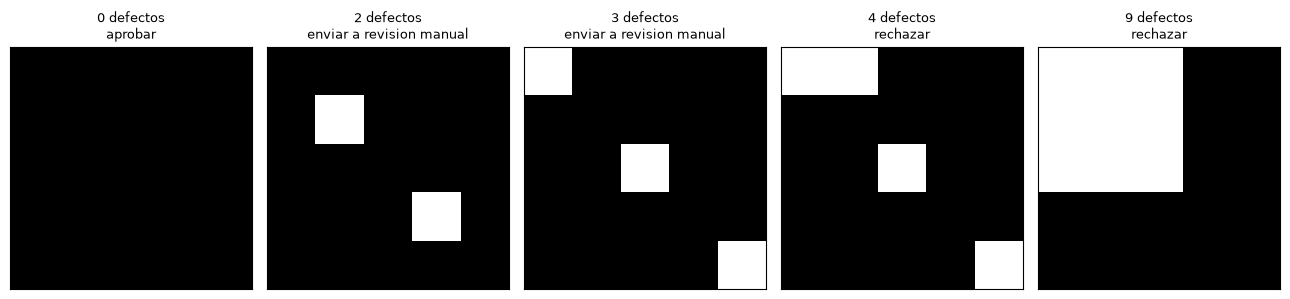

In [3]:
plt.figure(figsize=(13, 3))
for i in range(len(pruebas)):
    img = pruebas[i]
    accion, motivo = agente_inspeccion(img)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(str(int(img.sum())) + " defectos\n" + accion, fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


 
Lo más interesante es comparar img_3 con img_4: se diferencian en un solo píxel y sin embargo una
va a revisión manual y la otra se rechaza de frente. Eso muestra que el 3 no sale de la nada ni es
algo del producto, es una decisión de la fábrica: si lo mueven a 2 van a botar más productos buenos,
y si lo mueven a 4 se les van a escapar más fallados.